## Machine Temperature — Isolation Forest

Anomaly detection on the NAB `realKnownCause/machine_temperature_system_failure.csv` series using an Isolation Forest (IF) model. This series records internal machine temperature at hourly intervals and contains four labeled anomaly points corresponding to a real system failure event. The goal is to see whether an unsupervised IF model can identify these anomalies when scored on a rich feature set derived from the raw temperature signal.

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import IsolationForest
from sklearn.metrics import precision_score, recall_score, f1_score, average_precision_score

### Configuration

Set dataset path, feature engineering parameters, and random seed. `SEASONAL_PERIOD = 24` reflects the hourly cadence and daily cycle of the machine temperature series. Change `nab_rel_path` here to run the same pipeline on a different NAB series.

In [2]:
# --- Config ---
NAB_ROOT = Path("../NAB")  # change if needed
nab_rel_path = "realKnownCause/machine_temperature_system_failure.csv"

SEASONAL_PERIOD = 24       # hourly data → daily seasonality
ROLL_WINDOW = 24
TRAIN_FRAC = 0.7

RANDOM_STATE = 42

### Load Data and Labels

Load the CSV and attach NAB point labels from `combined_labels.json`. Labels are parsed as `datetime64` and joined to the DataFrame to avoid string-format mismatches. The machine temperature series has 22,695 rows; of these, 4 are labeled anomalies.

In [3]:
DATA_ROOT = NAB_ROOT / "data"
LABELS_PATH = NAB_ROOT / "labels" / "combined_labels.json"

with open(LABELS_PATH, "r") as f:
    combined_labels = json.load(f)

csv_path = DATA_ROOT / nab_rel_path
df = pd.read_csv(csv_path, parse_dates=["timestamp"]).sort_values("timestamp").reset_index(drop=True)

# Labels: parse as timestamps (avoid string-format mismatch)
label_ts = pd.to_datetime(combined_labels.get(nab_rel_path, []))
df["is_anomaly"] = df["timestamp"].isin(label_ts).astype(int)

df.head(), df["is_anomaly"].sum()


(            timestamp      value  is_anomaly
 0 2013-12-02 21:15:00  73.967322           0
 1 2013-12-02 21:20:00  74.935882           0
 2 2013-12-02 21:25:00  76.124162           0
 3 2013-12-02 21:30:00  78.140707           0
 4 2013-12-02 21:35:00  79.329836           0,
 np.int64(4))

### Train / Test Split

Split chronologically: the first 70% of timesteps form the training set (used to fit the model and derive thresholds), the remaining 30% the test set (used for evaluation only). The four labeled anomalies all fall in the test window.

In [4]:
def time_split(df: pd.DataFrame, train_frac: float = 0.7):
    split_idx = int(len(df) * train_frac)
    return df.iloc[:split_idx].copy(), df.iloc[split_idx:].copy()

train_df, test_df = time_split(df, TRAIN_FRAC)

(train_df.shape, test_df.shape, train_df["is_anomaly"].sum(), test_df["is_anomaly"].sum())

((15886, 3), (6809, 3), np.int64(2), np.int64(2))

### Feature Engineering

Build a nine-feature matrix from the raw `value` (temperature) series. Features capture local change, short-term and long-term rolling context, and seasonal deviation:

| Feature | Description |
|---|---|
| `delta1` | 1-step first difference — captures abrupt point changes |
| `delta24` | 24-step difference — removes daily cycle (same as seasonal diff) |
| `rolling_mean_24` | 24-step rolling mean of raw value |
| `rolling_std_24` | 24-step rolling std of raw value |
| `rolling_mean_168` | 168-step (7-day) rolling mean — long-term level |
| `long_dev` | Raw value minus 7-day mean — deviation from long-term baseline |
| `abs_seasonal_diff` | Absolute value of 24-step diff — unsigned deviation from yesterday |
| `rolling_std_24_raw` | Duplicate of `rolling_std_24` used for z-score calculation |
| `rolling_z_raw` | Rolling z-score: $(x_t - \mu_{24}) / (\sigma_{24} + \varepsilon)$ |

In [5]:
def make_features(df: pd.DataFrame, value_col="value", seasonal_period=24, roll_window=24):
    out = df.copy()

    # Raw amplitude context
    out["delta1"] = out[value_col].diff(1)
    out["delta24"] = out[value_col].diff(seasonal_period)

    # rolling context on raw values
    out["rolling_mean_24"] = out[value_col].rolling(roll_window, min_periods=roll_window//2).mean()
    out["rolling_std_24"]  = out[value_col].rolling(roll_window, min_periods=roll_window//2).std(ddof=0)

    # Long-term deviation (1 week)
    out["rolling_mean_168"] = out[value_col].rolling(168, min_periods=24).mean()
    out["long_dev"] = out[value_col] - out["rolling_mean_168"]

    # Absolute seasonal deviation (from raw seasonal difference)
    out["raw_seasonal_diff"] = out[value_col] - out[value_col].shift(seasonal_period)
    out["abs_seasonal_diff"] = out["raw_seasonal_diff"].abs()

    # Rolling z-score on raw values (explicit)
    out["rolling_std_24_raw"] = out[value_col].rolling(24, min_periods=12).std(ddof=0)
    out["rolling_z_raw"] = (out[value_col] - out[value_col].rolling(24, min_periods=12).mean()) / (out["rolling_std_24_raw"] + 1e-9)

    feature_cols = [
        "delta1",
        "delta24",
        "rolling_mean_24",
        "rolling_std_24",
        "rolling_mean_168",
        "long_dev",
        "abs_seasonal_diff",
        "rolling_std_24_raw",
        "rolling_z_raw",
    ]
    return out, feature_cols

feat_df, feature_cols = make_features(df, "value", SEASONAL_PERIOD, ROLL_WINDOW)
feat_df[["timestamp", "value", "is_anomaly"] + feature_cols].tail(10)

,timestamp,value,is_anomaly,delta1,delta24,rolling_mean_24,rolling_std_24,rolling_mean_168,long_dev,abs_seasonal_diff,rolling_std_24_raw,rolling_z_raw
22685,2014-02-19 14:40:00,96.739868,0,-0.028695,4.001476,95.332291,1.226602,93.356805,3.383063,4.001476,1.226602,1.147542
22686,2014-02-19 14:45:00,97.284578,0,0.544710,3.997614,95.498858,1.208846,93.388803,3.895775,3.997614,1.208846,1.477210
22687,2014-02-19 14:50:00,97.549774,0,0.265196,3.025937,95.624939,1.257403,93.417263,4.132511,3.025937,1.257403,1.530802
22688,2014-02-19 14:55:00,98.162952,0,0.613179,3.147494,95.756084,1.347881,93.454103,4.708849,3.147494,1.347881,1.785668
22689,2014-02-19 15:00:00,97.360905,0,-0.802047,3.955214,95.920885,1.291028,93.486284,3.874621,3.955214,1.291028,1.115406
22690,2014-02-19 15:05:00,98.185415,0,0.824510,4.060949,96.090091,1.310469,93.515566,4.669849,4.060949,1.310469,1.598912
22691,2014-02-19 15:10:00,97.804168,0,-0.381246,4.153314,96.263146,1.249755,93.544081,4.260088,4.153314,1.249755,1.233059
22692,2014-02-19 15:15:00,97.135468,0,-0.668700,2.793377,96.379536,1.194269,93.575390,3.560078,2.793377,1.194269,0.632966
22693,2014-02-19 15:20:00,98.056852,0,0.921384,3.439647,96.522855,1.180489,93.615280,4.441572,3.439647,1.180489,1.299459
22694,2014-02-19 15:25:00,96.903861,0,-1.152991,2.369786,96.621596,1.106820,93.637427,3.266434,2.369786,1.106820,0.255023


### Prepare Feature Arrays

Align features with the train/test split and drop rows containing NaN values (introduced by lag and rolling operations at the start of the series). Extract numpy arrays for the model.

In [14]:
train_feat = feat_df.loc[train_df.index].dropna(subset=feature_cols).copy()
test_feat  = feat_df.loc[test_df.index].dropna(subset=feature_cols).copy()

X_train = train_feat[feature_cols].values
X_test  = test_feat[feature_cols].values
y_test  = test_feat["is_anomaly"].astype(int).values

X_train.shape, X_test.shape, y_test.sum()

((15862, 9), (6809, 9), np.int64(2))

### Fit Isolation Forest

Train an Isolation Forest on the training feature matrix. Key hyperparameters:

- `n_estimators=800` — more trees than the default (100) for a stabler score surface
- `contamination=0.050` — rough prior for tree splitting; final thresholding is handled by the alert budget sweep below
- `max_samples=256` — subsample size per tree; smaller values increase diversity and speed
- `max_features=0.8` — each tree sees 80% of features, reducing correlation between trees

The raw `decision_function` output is negated so that **higher score = more anomalous**, consistent with the MAD baseline convention.

In [15]:
iforest = IsolationForest(
    n_estimators=800,
    contamination=0.050,     # rough prior; final alerting controlled by thresholding
    random_state=RANDOM_STATE,
    n_jobs=-1,
    max_samples=256,
    max_features=0.8
)

iforest.fit(X_train)

# Invert decision_function so higher = more anomalous
train_feat["if_score"] = -iforest.decision_function(X_train)
test_feat["if_score"]  = -iforest.decision_function(X_test)

test_feat[["timestamp", "value", "is_anomaly", "if_score"]].head()

,timestamp,value,is_anomaly,if_score
15886,2014-01-27 00:05:00,88.482330,0,-0.205065
15887,2014-01-27 00:10:00,86.688731,0,-0.162293
15888,2014-01-27 00:15:00,88.053503,0,-0.193645
15889,2014-01-27 00:20:00,88.442419,0,-0.205787
15890,2014-01-27 00:25:00,87.257083,0,-0.194712


### Alert Budget Sweep

Evaluate the IF model across a tight range of alert budgets (4.0%–5.0%, step 0.1%). For each budget, the threshold is set to the corresponding percentile of the **training** score distribution — no test labels used. Metrics reported:

- **precision / recall / F1** — point-level against NAB labels
- **AP** — average precision (area under the precision-recall curve)
- **alert_rate_actual** — fraction of test steps that fire at this threshold

In [16]:
def eval_at_alert_budget(train_scores, test_scores, y_true, alert_rate):
    p = 100 * (1 - alert_rate)                # e.g., 99 for 1% alert budget
    t = np.percentile(train_scores, p)        # threshold derived from TRAIN only

    y_pred = (test_scores > t).astype(int)

    return {
        "alert_rate_target": alert_rate,
        "threshold_percentile": p,
        "threshold": float(t),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "alerts": int(y_pred.sum()),
        "alert_rate_actual": float(y_pred.mean()),
        "ap": float(average_precision_score(y_true, test_scores)) if y_true.sum() > 0 else np.nan,
    }, y_pred

train_scores = train_feat["if_score"].values
test_scores  = test_feat["if_score"].values

budgets = list(np.round(np.arange(0.04, 0.0501, 0.001), 3))

rows = []
preds = {}

for b in budgets:
    row, y_pred = eval_at_alert_budget(train_scores, test_scores, y_test, b)
    rows.append(row)
    preds[b] = y_pred

results_if = pd.DataFrame(rows).sort_values("f1", ascending=False)
results_if

,alert_rate_target,threshold_percentile,threshold,precision,recall,f1,alerts,alert_rate_actual,ap
10,0.050,95.0,-2.392546e-16,0.004348,1.0,0.008658,460,0.067558,0.00355
5,0.045,95.5,6.172883e-03,0.002618,0.5,0.005208,382,0.056102,0.00355
6,0.046,95.4,5.513455e-03,0.002551,0.5,0.005076,392,0.057571,0.00355
7,0.047,95.3,3.688867e-03,0.002445,0.5,0.004866,409,0.060068,0.00355
8,0.048,95.2,2.454799e-03,0.002331,0.5,0.004640,429,0.063005,0.00355
9,0.049,95.1,9.580805e-04,0.002222,0.5,0.004425,450,0.066089,0.00355
0,0.040,96.0,1.461864e-02,0.000000,0.0,0.000000,317,0.046556,0.00355
1,0.041,95.9,1.332195e-02,0.000000,0.0,0.000000,321,0.047143,0.00355
2,0.042,95.8,1.127184e-02,0.000000,0.0,0.000000,332,0.048759,0.00355
3,0.043,95.7,1.004227e-02,0.000000,0.0,0.000000,342,0.050228,0.00355


### Anomaly Score Ranking

Rank all test points by their IF score (rank 1 = most anomalous) and inspect where the four labeled anomalies fall. If the model is discriminative, labeled anomalies should appear near the top of the ranking with high percentile ranks.

In [17]:
test_feat["rank"] = test_feat["if_score"].rank(ascending=False)
test_feat.loc[test_feat["is_anomaly"] == 1, ["timestamp", "if_score", "rank"]]

,timestamp,if_score,rank
16340,2014-01-28 13:55:00,0.007453,371.0
19515,2014-02-08 14:30:00,0.000631,454.0


### Near-Hit Evaluation

Exact timestamp matching is too strict for operational use. `near_hit_evaluation` relaxes matching to a configurable time tolerance (default: ±60 min):

- A labeled anomaly is **hit** if any prediction falls within the tolerance window around it.
- Reports recall over anomaly events, matched predictions, and total alerts.

For the machine temperature series the hourly cadence means ±60 min allows one step of slack in either direction. Results are shown across all budgets in the sweep.

In [18]:
def near_hit_evaluation(
    df,
    pred_col,
    ts_col="timestamp",
    label_col="is_anomaly",
    tolerance="60min",
):
    """
    Computes near-hit recall within a specified time tolerance.

    Returns:
        recall (float)
        matched_true (int)
        total_true (int)
        matched_predictions (int)
        total_predictions (int)
    """
    tol = pd.Timedelta(tolerance)

    true_ts = df.loc[df[label_col] == 1, ts_col].sort_values()
    pred_ts = df.loc[df[pred_col] == 1, ts_col].sort_values()

    total_true = len(true_ts)
    total_pred = len(pred_ts)

    if total_true == 0:
        return 0.0, 0, 0, 0, total_pred

    matched_true = 0
    matched_pred_indices = set()

    for i, t in enumerate(true_ts):
        # Find predictions within tolerance
        mask = (pred_ts >= t - tol) & (pred_ts <= t + tol)
        if mask.any():
            matched_true += 1
            # Track which prediction(s) were used
            matched_pred_indices.update(pred_ts[mask].index.tolist())

    recall = matched_true / total_true
    matched_predictions = len(matched_pred_indices)

    return recall, matched_true, total_true, matched_predictions, total_pred

In [19]:
for b in budgets:
    tmp = test_feat.copy()
    tmp["pred"] = preds[b]
    result = near_hit_evaluation(tmp, pred_col="pred", tolerance="60min")
    print(f"alert_budget={int(b*100)}%  near-hit recall={result[0]:.3f}  matched={result[1]}/{result[2]}  pred_alerts={result[4]}")

alert_budget=4%  near-hit recall=0.000  matched=0/2  pred_alerts=317
alert_budget=4%  near-hit recall=0.500  matched=1/2  pred_alerts=321
alert_budget=4%  near-hit recall=1.000  matched=2/2  pred_alerts=332
alert_budget=4%  near-hit recall=1.000  matched=2/2  pred_alerts=342
alert_budget=4%  near-hit recall=1.000  matched=2/2  pred_alerts=361
alert_budget=4%  near-hit recall=1.000  matched=2/2  pred_alerts=382
alert_budget=4%  near-hit recall=1.000  matched=2/2  pred_alerts=392
alert_budget=4%  near-hit recall=1.000  matched=2/2  pred_alerts=409
alert_budget=4%  near-hit recall=1.000  matched=2/2  pred_alerts=429
alert_budget=4%  near-hit recall=1.000  matched=2/2  pred_alerts=450
alert_budget=5%  near-hit recall=1.000  matched=2/2  pred_alerts=460


### Score Distribution

Plot the distribution of IF scores on the test set. The vertical red line marks the mean score of the four labeled anomaly points. If the model separates anomalies from normal behaviour, labeled points should sit in the right tail well away from the bulk of the distribution.

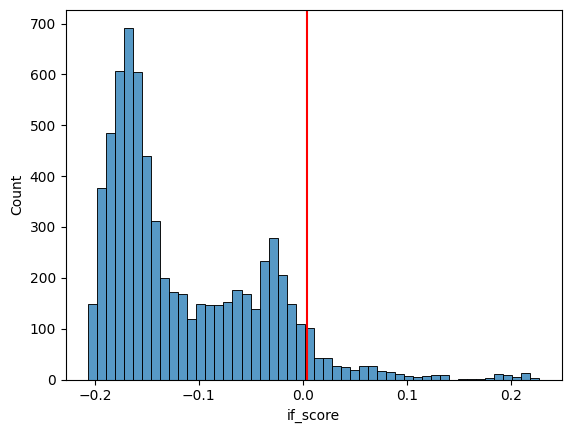

In [20]:
import seaborn as sns

sns.histplot(test_feat["if_score"], bins=50)
plt.axvline(test_feat.loc[test_feat["is_anomaly"] == 1, "if_score"].mean(), color="red")
plt.show()

### Percentile Rank of Labeled Anomalies

Show what percentile each labeled anomaly's IF score falls at relative to the full test set. A value of `0.95` means the score is higher than 95% of all test points. Values close to `1.0` indicate the model ranks that anomaly near the top of the list.

In [21]:
test_feat.loc[test_feat["is_anomaly"] == 1, "if_score"].rank(pct=True)

16340    1.0
19515    0.5
Name: if_score, dtype: float64